# EfficientNetB0 Transfer‑Learning Project
A complete, **drop‑in Colab notebook** that swaps your custom CNN for EfficientNetB0, adds data augmentation, and fine‑tunes the last layers for higher accuracy.

📌 **Before you run**: Place your dataset in a single folder with sub‑folders named after each class, or mount Google Drive and point `data_dir` there.

In [ ]:
!pip uninstall -y keras_cv tensorflow-text tensorflow-decision-forests keras-nightly keras-preprocessing
!pip install -U tensorflow==2.18.0 --quiet


Found existing installation: keras-cv 0.6.2
Uninstalling keras-cv-0.6.2:
  Successfully uninstalled keras-cv-0.6.2
Found existing installation: tensorflow-text 2.18.1
Uninstalling tensorflow-text-2.18.1:
  Successfully uninstalled tensorflow-text-2.18.1


In [ ]:
import os
os.kill(os.getpid(), 9)


In [ ]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

print("✅ TensorFlow version:", tf.__version__)


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


## 1  Load the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
data_dir = '/content/drive/MyDrive/ML practice/practice1/unziped/train/train'
img_size   = (224, 224)
batch_size = 32
seed       = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)
class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
['cats', 'dogs']


## 2  Data augmentation

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE
def augment(image, label):
    return data_augmentation(image), label

augmented_train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

## 3  Build the EfficientNetB0 model

In [ ]:
# --- BASE -----------------------------------------------------------
base_model = EfficientNetB0(include_top=False,
                           weights='imagenet',
                           input_shape=(*img_size, 3))
base_model.trainable = False

# --- HEAD -----------------------------------------------------------
inputs  = keras.Input(shape=(*img_size, 3))
x       = preprocess_input(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.25)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.compile(optimizer=keras.optimizers.Adam(1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 4  Stage‑1 training (frozen backbone)

In [ ]:
hist_frozen = model.fit(
    augmented_train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 459s 732ms/step - accuracy: 0.9722 - loss: 0.0987 - val_accuracy: 0.9882 - val_loss: 0.0499
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 277s 443ms/step - accuracy: 0.9775 - loss: 0.0727 - val_accuracy: 0.9900 - val_loss: 0.0387
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 279s 373ms/step - accuracy: 0.9804 - loss: 0.0600 - val_accuracy: 0.9908 - val_loss: 0.0334
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 269s 431ms/step - accuracy: 0.9815 - loss: 0.0557 - val_accuracy: 0.9916 - val_loss: 0.0299
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 228s 365ms/step - accuracy: 0.9828 - loss: 0.0510 - val_accuracy: 0.9914 - val_loss: 0.0281
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 265s 369ms/step - accuracy: 0.9834 - loss: 0.0473 - val_accuracy: 0.9914 - val_loss: 0.0268
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 237s 379ms/step - accuracy: 0.9855 - loss: 0.0442 - val_accuracy: 0.9920 - val_loss: 0.0256
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 229s 366ms/step - accuracy: 0.9826 -

## 5  Fine‑tune the top EfficientNet layers

In [ ]:
# Unfreeze last 30 layers (except BatchNorm)
for layer in base_model.layers[-30:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

hist_ft = model.fit(
    augmented_train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[
        keras.callbacks.ModelCheckpoint('best_efficientnet.h5', save_best_only=True, monitor='val_accuracy'),
        keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=2, min_lr=1e-6)
    ]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9856 - loss: 0.0383

625/625 ━━━━━━━━━━━━━━━━━━━━ 263s 380ms/step - accuracy: 0.9856 - loss: 0.0383 - val_accuracy: 0.9930 - val_loss: 0.0215 - learning_rate: 1.0000e-05
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 234s 373ms/step - accuracy: 0.9865 - loss: 0.0371 - val_accuracy: 0.9924 - val_loss: 0.0204 - learning_rate: 1.0000e-05
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 235s 375ms/step - accuracy: 0.9864 - loss: 0.0323 - val_accuracy: 0.9928 - val_loss: 0.0204 - learning_rate: 1.0000e-05
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9876 - loss: 0.0313

625/625 ━━━━━━━━━━━━━━━━━━━━ 305s 444ms/step - accuracy: 0.9876 - loss: 0.0313 - val_accuracy: 0.9932 - val_loss: 0.0198 - learning_rate: 1.0000e-05
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 232s 370ms/step - accuracy: 0.9888 - loss: 0.0287 - val_accuracy: 0.9930 - val_loss: 0.0193 - learning_rate: 1.0000e-05
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.9909 - loss: 0.0272

625/625 ━━━━━━━━━━━━━━━━━━━━ 234s 373ms/step - accuracy: 0.9909 - loss: 0.0272 - val_accuracy: 0.9940 - val_loss: 0.0193 - learning_rate: 1.0000e-05
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 232s 371ms/step - accuracy: 0.9904 - loss: 0.0279 - val_accuracy: 0.9936 - val_loss: 0.0191 - learning_rate: 1.0000e-05
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 278s 443ms/step - accuracy: 0.9899 - loss: 0.0280 - val_accuracy: 0.9934 - val_loss: 0.0193 - learning_rate: 1.0000e-05
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 234s 374ms/step - accuracy: 0.9908 - loss: 0.0236 - val_accuracy: 0.9940 - val_loss: 0.0198 - learning_rate: 1.0000e-05
Epoch 10/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 303s 439ms/step - accuracy: 0.9904 - loss: 0.0247 - val_accuracy: 0.9936 - val_loss: 0.0197 - learning_rate: 2.0000e-06


## 6  Evaluate on the validation set

In [ ]:
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f'Validation accuracy: {val_acc:.4f}')

Validation accuracy: 0.9936


## 7  Plot training curves

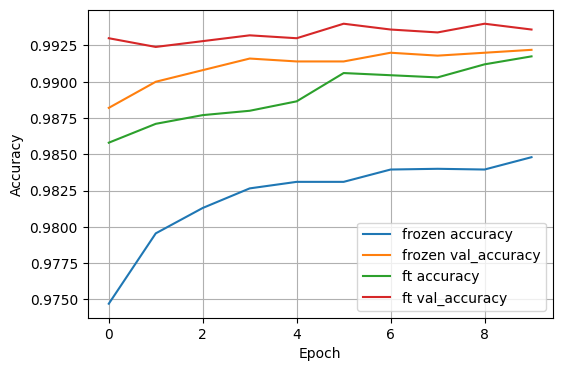

In [ ]:
def plot_history(histories, metric='accuracy'):
    plt.figure(figsize=(6,4))
    for label, history in histories.items():
        plt.plot(history.history[metric], label=f'{label} {metric}')
        plt.plot(history.history['val_'+metric], label=f'{label} val_{metric}')
    plt.legend()
    plt.xlabel('Epoch')
    plt.ylabel(metric.title())
    plt.grid(True)
    plt.show()

plot_history({'frozen': hist_frozen, 'ft': hist_ft})

## 8  Save the final model

In [ ]:
model.save('efficientnetb0_final_cat_vs_dog.h5')
print('Model saved to efficientnetb0_final.h5')


Model saved to efficientnetb0_final.h5
